# Plano inclinado oscilante
Unidad: Fuerzas no conservativas

[ingenieria_logo_schwarz.png](https://ingenieria.unlam.edu.ar/)  
[by-nc-sa_80x15.png](https://creativecommons.org/licenses/by-sa/4.0/deed.es_ES) 
2026 [Víctor A. Bettachini](mailto:vbettachini@unlam.edu.ar)  

---

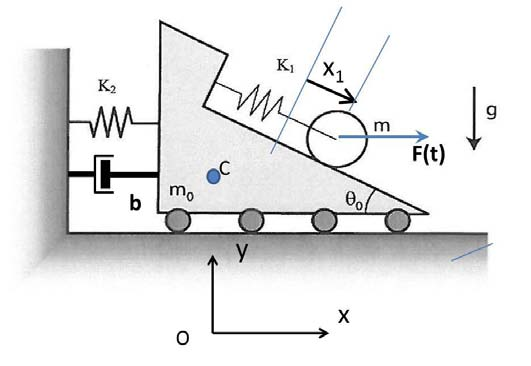

Sobre la superficie inclinada en $\theta_0$ del carro de masa $m_0$ rueda sin deslizar un disco de radio $R$ y masa $m$.
Este no se sale de la superficie a pesar de que al centro del mismo se aplica una fuerza $\vec{F}= F(t) \hat{x}$ gracias a un resorte de constante elástica $K_1$ que une este centro con el carro.
Limita el alcance de este un resorte de constante elástica $K_2$ fijado a la pared y un amortiguador proporcional a la velocidad de constante proporcional $b$.
Ambos resortes tienen originalmente sus longitudes naturales, $l_{10}$ y $l_{20}$.
Se descarta la fricción del carro con el suelo.
Todo el sistema está sometido a la aceleración gravitatoria $\vec{g}= - g \hat{y}$.

## Tareas


### a) Justifique su repuesta a esta pregunta conceptual
¿Cuál es la fuerza generalizada asociada al desplazamiento virtual $\delta x$ debida a $\vec{F}$?

- $F(t) \cos(\theta)$
- $F(t)$
- $F(t) \delta x$
- $0$

### b) Obtenga la dinámica a partir de las ecuaciones de Euler-Lagrange
Esto es, haga explícitas las aceleraciones de ambos cuerpos.

Resultado:
$$
	\ddot{x} = \frac{2 K_{1} X_{1} \cos{\left(\theta_{0} \right)} - 3 K_{2} x - 3 b \dot{x} - g m \sin{\left(2 \theta_{0} \right)} - F \cos{\left(2 \theta_{0} \right)} + 2 F}{2 m \sin^{2}{\left(\theta_{0} \right)} + m + 3 m_{0}}
$$

$$
	\ddot{X}_{1} = \frac{2 \left(- K_{1} m X_{1} - K_{1} m_{0} X_{1} + K_{2} m x \cos{\left(\theta_{0} \right)} + b m \cos{\left(\theta_{0} \right)} \dot{x} + g m^{2} \sin{\left(\theta_{0} \right)} + g m m_{0} \sin{\left(\theta_{0} \right)} + m_{0} F \cos{\left(\theta_{0} \right)}\right)}{m \left(2 m \sin^{2}{\left(\theta_{0} \right)} + m + 3 m_{0}\right)}
$$

## Resolución

In [ ]:
import sympy as sm # importamos funciones de cálculo simbólico
from sympy.physics import mechanics as me # de sympy utilizaremos funciones de mecánica
me.init_vprinting() # notación con punto para la velocidad y punto punto para la aceleración

In [ ]:
def energia_cinetica_traslacion(masa, posicion, marco_referencia):
    r"""Calcula la energía cinética traslacional de una partícula puntual.
    
    La energía cinética se calcula como:
        T = (1/2) * m * v · v
    donde v es la velocidad de la partícula en el marco de referencia dado.
    
    Parámetros
    ----------
    masa : sympy.core.symbol.Symbol
        Masa de la partícula
    posicion : sympy.physics.vector.vector.Vector
        Vector de posición del centro de masa de la partícula
    marco_referencia : sympy.physics.vector.frame.ReferenceFrame
        Marco de referencia en el que se expresa la posición y velocidad
    
    Devuelve
    -------
    sympy.core.mul.Mul
        Energía cinética traslacional de la partícula.
        Puede depender de coordenadas, velocidades generalizadas y tiempo.
    """
    # Calcular velocidad en el marco de referenciac
    velocidad = posicion.dt(marco_referencia)
    
    # Calcular energía cinética: T = (1/2) * m * v·v
    factor_un_medio = sm.Rational(1, 2)
    energia_cinetica = (factor_un_medio * masa * velocidad.dot(velocidad))
    
    # Simplificar la expresión resultante
    return energia_cinetica.simplify()

In [ ]:
def energia_cinetica_rotacion(momento_inercia, velocidad_angular):
    """
    Calcula la energía cinética de un cuerpo extenso (no puntual) que rota en torno a un eje.

    Parámetros
    ----------
    momento_inercia : Multiplicación Sympy (sympy.core.mul.Mul)
        Expresada en referencia al eje de rotación para la velocidad_angular.
    velocidad_angular : sympy.physics.vector.vector.Vector
        Velocidad de rotación en torno a un eje.
 
    Devuelve
    -------
    sympy.core.mul.Mul
        Energía cinética de rotación (I/2)* omega**2
    """
    unMedio = sm.Rational(1,2) # Rational: fracción de enteros, alternativamente podría haberse usado 0.5
    return unMedio* momento_inercia* velocidad_angular.dot(velocidad_angular)

In [ ]:
def energia_potencial_gravitatoria(masa, posicion, aceleracion_gravitatoria):
    r"""Calcula la energía potencial gravitatoria de una partícula.
    
    La energía potencial se calcula como:
        V = -m * (g · r)
    donde:
        m = masa de la partícula
        g = vector aceleración gravitatoria  
        r = vector posición de la partícula
    
    Parámeteros
    ----------
    masa : sympy.core.symbol.Symbol
        Masa de la partícula
    posicion : sympy.physics.vector.vector.Vector
        Vector de posición del centro de masa de la partícula
    aceleracion_gravitatoria : sympy.physics.vector.vector.Vector
        Vector de aceleración gravitatoria en el sistema de referencia
    
    Devuelve
    -------
    sympy.core.mul.Mul
        Energía potencial gravitatoria de la partícula.
        Puede depender de coordenadas generalizadas y tiempo.
    """
    # Calcular energía potencial: V = -m * (g · r)
    producto_gravitatorio = (masa * aceleracion_gravitatoria).dot(posicion)
    energia_potencial = -producto_gravitatorio
    
    # Simplificar la expresión resultante
    return energia_potencial.simplify()

In [ ]:
def energia_potencial_elastica(constante_elastica, posicion_particula, posicion_equilibrio):
    r"""Calcula la energía potencial elástica de un resorte.
    
    La energía potencial se calcula como:
        V = (1/2) * k * (x - x0)^2
    donde:
        k = constante elástica del resorte
        x = posición de la partícula
        x0 = posición de equilibrio del resorte
    
    Parámetros
    ----------
    constante_elastica : sympy.core.symbol.Symbol
        Constante elástica del resorte
        
    posicion_particula : sympy.physics.vector.vector.Vector
        Vector de posición de la partícula en el extremo libre del resorte
        
    posicion_equilibrio : sympy.physics.vector.vector.Vector
        Vector de posición de equilibrio del resorte
    
    Devuelve
    -------
    sympy.core.mul.Mul
        Energía potencial elástica del resorte.
        Puede depender de coordenadas generalizadas y tiempo.
    """
    # Calcular estiramiento del resorte: x - x0
    estiramiento = posicion_particula - posicion_equilibrio
    
    # Calcular energía potencial: V = (1/2) * k * (x - x0)^2
    energia_potencial = sm.Rational(1, 2) * constante_elastica * estiramiento.dot(estiramiento)
    
    # Simplificar la expresión resultante
    return energia_potencial.simplify()

In [ ]:
def euler_lagrange_homogenea(T, V, q):
    r"""Calcula la ecuación de Euler-Lagrange homogénea para la coordenada generalizada q.
    
    La ecuación se obtiene a partir del lagrangiano L = T - V:
        d/dt(∂L/∂q̇) - ∂L/∂q = 0
    
    donde:
        T = energía cinética
        V = energía potencial  
        q = coordenada generalizada
        q̇ = derivada temporal de la coordenada generalizada
    
    Parámetros
    ----------
    T : sympy.core.relational.Equality
        Igualdad Sympy cuyo lado derecho contiene la energía cinética del sistema
        en función de coordenadas, velocidades generalizadas y tiempo.
    V : sympy.core.relational.Equality
        Igualdad Sympy cuyo lado derecho contiene la energía potencial del sistema
        en función de coordenadas, velocidades generalizadas y tiempo.
    q : sympy.core.symbol.Symbol
        Coordenada generalizada para la cual se calcula la ecuación de Euler-Lagrange
    
    Retorna
    -------
    sympy.core.relational.Equality
        Ecuación de Euler-Lagrange homogénea para la coordenada generalizada
    """
    # Calcular el lagrangiano: L = T - V
    lagrangiano = (T - V).expand()
    
    # Definir variable tiempo para derivadas temporales
    t = sm.Symbol('t')
    
    # Calcular ecuación de Euler-Lagrange: d/dt(∂L/∂q̇) - ∂L/∂q = 0
    termino_simil_masa_aceleracion = lagrangiano.diff(q.diff(t)).diff(t)
    termino_simil_fuerzas_conservativas = lagrangiano.diff(q)
    
    # Formar la ecuación de Euler-Lagrange homogénea (igualada a cero)
    ecuacion = sm.Eq(termino_simil_masa_aceleracion - termino_simil_fuerzas_conservativas, 0)
    
    return ecuacion.simplify()

In [ ]:
### A partir de aquí su código